## 📍 Sub-Proyek 4: Promo, Discount & Minimum Order Value Effectiveness

### 🎯 Tujuan Analisis:
1. **Promo & Discount Intensity Engineering**: Menghitung intensitas diskon (*Markdown & Value Perception*) dari `price_history.csv` dan `Estimated_value_score` pada `restaurant_statistics.csv`.
2. **Order Barrier & Friction Ratio**: Menganalisis rasio ambang batas pesanan minimum (`Minimum_order`) terhadap rata-rata harga menu (`Average_menu_price`) dalam basis terstandardisasi ($USD).
3. **Econometric Elasticity & Causal Modeling**: Mengukur elastisitas diskon dan friksi minimum order terhadap proksi volume pesanan (`Popularity_score`, `Review_count`) serta kepuasan pelanggan (`Average_rating`).
4. **Promo Optimization Framework**: Memetakan strategi promo optimal per kuadran bisnis untuk memaksimalkan ROI restoran dan volume platform.

In [8]:
# ==============================================================================
# 1. SETUP ENVIRONMENT & DEPENDENCIES
# ==============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats & Econometrics
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Konfigurasi Warning & Formatting
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Styling Plot
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("✅ Setup dependencies Sub-Proyek 4 selesai.")

✅ Setup dependencies Sub-Proyek 4 selesai.


In [9]:
# ==============================================================================
# 2. INGESTION DATASET & RELATIONAL MERGING
# ==============================================================================
DATASET_PATH = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/data"

def load_subproject4_data(path=DATASET_PATH):
    print("📂 Memuat tabel data relasional untuk analisis promo & diskon...")
    
    restaurants_df = pd.read_csv(os.path.join(path, "restaurants.csv"))
    delivery_df = pd.read_csv(os.path.join(path, "delivery_metrics.csv"))
    rest_stats_df = pd.read_csv(os.path.join(path, "restaurant_statistics.csv"))
    price_hist_df = pd.read_csv(os.path.join(path, "price_history.csv"))
    menus_df = pd.read_csv(os.path.join(path, "menus.csv"))
    cities_df = pd.read_csv(os.path.join(path, "cities.csv"))
    countries_df = pd.read_csv(os.path.join(path, "countries.csv"))

    # 1. Hitung agregasi diskon/promo per restoran dari price_history & menus
    price_menu = price_hist_df.merge(
        menus_df[['Menu_ID', 'Restaurant_ID', 'Price']], 
        on='Menu_ID', 
        how='inner'
    )
    
    # Hitung rata-rata diskon (penurunan harga) dan frekuensi promo
    promo_agg = price_menu.groupby('Restaurant_ID').agg(
        Total_Promo_Events=('Price_change', 'count'),
        Avg_Discount_Nominal=('Price_change', lambda x: x[x < 0].abs().mean() if (x < 0).any() else 0.0),
        Max_Discount_Nominal=('Price_change', lambda x: x[x < 0].abs().max() if (x < 0).any() else 0.0),
        Avg_Price_Markdown_Pct=('Price_change', lambda x: ((x[x < 0].abs() / price_menu.loc[x[x < 0].index, 'Previous_price']).mean() * 100) if (x < 0).any() else 0.0)
    ).reset_index()

    # 2. Gabungkan restoran dengan metrik delivery, statistik, dan promo
    master_rest = restaurants_df.merge(delivery_df, on='Restaurant_ID', how='left')
    master_rest = master_rest.merge(rest_stats_df[['Restaurant_ID', 'Average_menu_price', 'Popularity_score', 'Estimated_value_score']], on='Restaurant_ID', how='left')
    master_rest = master_rest.merge(promo_agg, on='Restaurant_ID', how='left')
    master_rest = master_rest.merge(cities_df[['City', 'Country', 'Cost_of_living_index', 'Average_income']], on=['City', 'Country'], how='left')
    master_rest = master_rest.merge(countries_df[['Country', 'Currency', 'Region']], on='Country', how='left')

    print(f"📊 Master Promo Dataset terbentuk: {master_rest.shape[0]:,} baris restoran.")
    return master_rest

promo_master = load_subproject4_data()

📂 Memuat tabel data relasional untuk analisis promo & diskon...
📊 Master Promo Dataset terbentuk: 5,000 baris restoran.


In [10]:
# ==============================================================================
# 3. FEATURE ENGINEERING & PROMO METRIC CONVERSIONS
# ==============================================================================

# A. Standardisasi Mata Uang (FX ke USD)
fx_rates = {
    'USD': 1.0000,
    'GBP': 1.2800,
    'BRL': 0.1800,
    'INR': 0.0120,
    'JPY': 0.0065
}

promo_master['FX_Rate'] = promo_master['Currency'].map(fx_rates).fillna(1.0)
promo_master['Minimum_order_USD'] = promo_master['Minimum_order'] * promo_master['FX_Rate']
promo_master['Average_menu_price_USD'] = promo_master['Average_menu_price'] * promo_master['FX_Rate']
promo_master['Avg_Discount_USD'] = promo_master['Avg_Discount_Nominal'].fillna(0) * promo_master['FX_Rate']

# B. Rekayasa Metrik Promo & Friksi Pesanan
# 1. Total Value / Promo Attractiveness Score (0-100 scale)
# Mengombinasikan Estimated_value_score (skala 1-10) dengan persentase markdown diskon
promo_master['Promo_Attractiveness_Score'] = (
    (promo_master['Estimated_value_score'].fillna(5.0) * 7.0) + 
    (promo_master['Avg_Price_Markdown_Pct'].fillna(0.0) * 0.3)
).clip(0, 100)

# 2. Min Order Barrier Ratio (Ambang batas minimum order terhadap harga rata-rata 1 menu)
# Rasio > 2.0 berarti konsumen wajib membeli minimal 2-3 menu sekaligus untuk dapat memesan
promo_master['Min_Order_Friction_Ratio'] = (
    promo_master['Minimum_order_USD'] / (promo_master['Average_menu_price_USD'] + 1e-6)
).clip(0, 10)

# 3. Order Volume Index (Composite Volume Proxy)
# Menggabungkan Popularity_score (0-100) dan Review_count ter-normalisasi
log_reviews = np.log1p(promo_master['Review_count'].fillna(0))
promo_master['Normalized_Review_Score'] = (log_reviews / log_reviews.max()) * 100
promo_master['Composite_Volume_Index'] = (
    (promo_master['Popularity_score'].fillna(50) * 0.6) + 
    (promo_master['Normalized_Review_Score'] * 0.4)
)

# C. Klasifikasi Kebijakan Promo Restoran (2x2 Matrix Strategy)
def classify_promo_strategy(row):
    high_promo = row['Promo_Attractiveness_Score'] >= promo_master['Promo_Attractiveness_Score'].median()
    high_barrier = row['Min_Order_Friction_Ratio'] >= promo_master['Min_Order_Friction_Ratio'].median()
    
    if high_promo and not high_barrier:
        return 'Growth Driver (High Promo, Low Barrier)'
    elif high_promo and high_barrier:
        return 'Basket Maximizer (High Promo, High Barrier)'
    elif not high_promo and not high_barrier:
        return 'Organic Frictions-Free (Low Promo, Low Barrier)'
    else:
        return 'Strict Gatekeeper (Low Promo, High Barrier)'

promo_master['Promo_Strategy_Segment'] = promo_master.apply(classify_promo_strategy, axis=1)

print("✅ Rekayasa fitur promo dan segmentasi strategi selesai.")
display(promo_master[['Restaurant_name', 'City', 'Promo_Attractiveness_Score', 'Min_Order_Friction_Ratio', 'Composite_Volume_Index', 'Promo_Strategy_Segment']].head(5))

✅ Rekayasa fitur promo dan segmentasi strategi selesai.


,Restaurant_name,City,Promo_Attractiveness_Score,Min_Order_Friction_Ratio,Composite_Volume_Index,Promo_Strategy_Segment
0,Thai Chain 0,New York,50.40,0.01,94.27,"Growth Driver (High Promo, Low Barrier)"
1,Los Angeles Italian Place 1,Los Angeles,46.20,0.11,88.40,"Growth Driver (High Promo, Low Barrier)"
2,Italian Chain 2,Manchester,10.50,NaN,81.02,"Organic Frictions-Free (Low Promo, Low Barrier)"
3,London Chinese Place 3,London,49.00,NaN,58.49,"Growth Driver (High Promo, Low Barrier)"
4,Chinese Chain 4,Osaka,7.00,0.75,97.14,"Strict Gatekeeper (Low Promo, High Barrier)"


In [11]:
# ==============================================================================
# 4. REGRESI EKONOMETRIKA: ESTIMASI ELASTISITAS PROMO & AMBANG BATAS
# ==============================================================================

# Siapkan data regresi (lengkap & bersih dari nilai null)
reg_df = promo_master[[
    'Composite_Volume_Index', 'Average_rating', 'Promo_Attractiveness_Score',
    'Min_Order_Friction_Ratio', 'Price_level', 'Cost_of_living_index', 
    'Cancellation_rate', 'Delivery_fee'
]].dropna().copy()

# Model 1: Pengaruh Promo & Minimum Order terhadap Volume Pesanan (Composite Volume Index)
model_volume = ols(
    'Composite_Volume_Index ~ Promo_Attractiveness_Score + Min_Order_Friction_Ratio + Price_level + Cost_of_living_index',
    data=reg_df
).fit()

# Model 2: Pengaruh Promo & Friction terhadap Kepuasan Konsumen (Average Rating)
model_rating = ols(
    'Average_rating ~ Promo_Attractiveness_Score + Min_Order_Friction_Ratio + Cancellation_rate + Price_level',
    data=reg_df
).fit()

print("📈 MODEL 1: DETERMINAN VOLUME PESANAN (COMPOSITE VOLUME INDEX)")
print(model_volume.summary().tables[1])

print("\n⭐ MODEL 2: DETERMINAN KEPUASAN PELANGGAN (AVERAGE RATING)")
print(model_rating.summary().tables[1])

📈 MODEL 1: DETERMINAN VOLUME PESANAN (COMPOSITE VOLUME INDEX)
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     64.8838      1.648     39.382      0.000      61.653      68.114
Promo_Attractiveness_Score     0.0222      0.015      1.439      0.150      -0.008       0.052
Min_Order_Friction_Ratio      -0.1962      1.443     -0.136      0.892      -3.025       2.632
Price_level                   -0.7910      0.340     -2.324      0.020      -1.458      -0.124
Cost_of_living_index           0.0265      0.014      1.849      0.065      -0.002       0.055

⭐ MODEL 2: DETERMINAN KEPUASAN PELANGGAN (AVERAGE RATING)
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept               

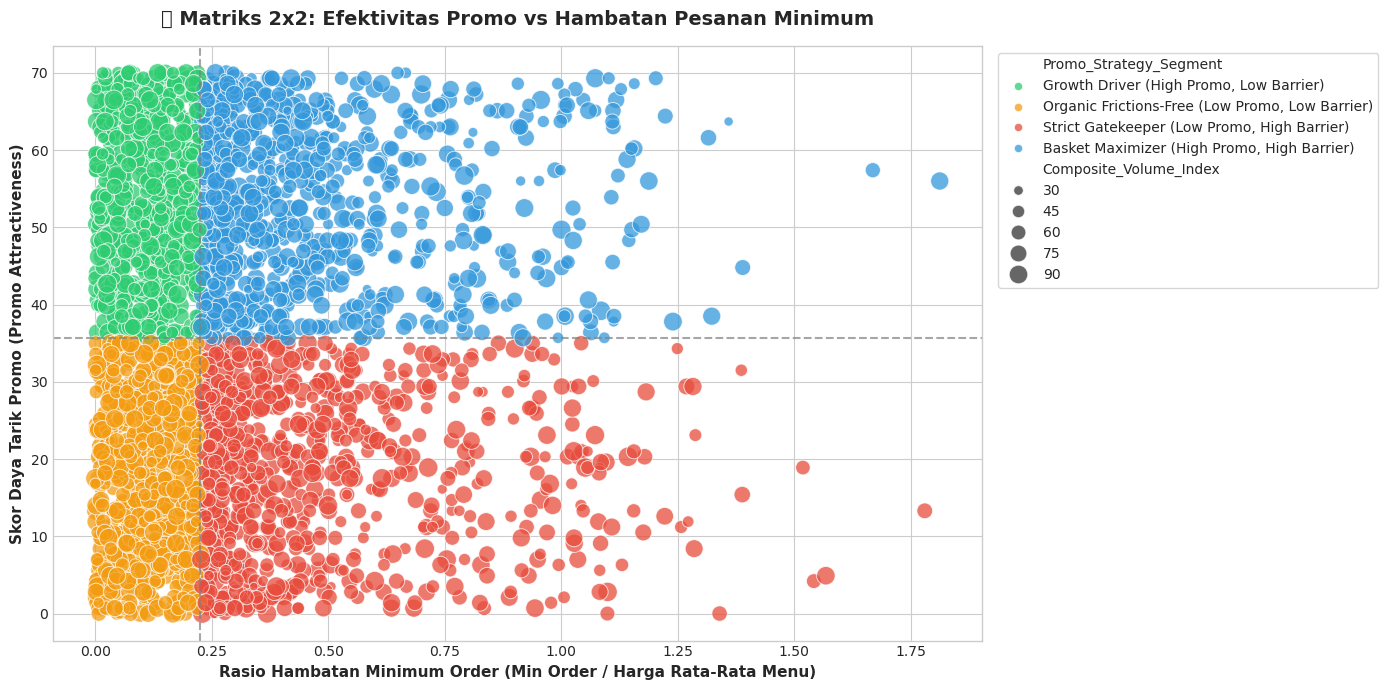

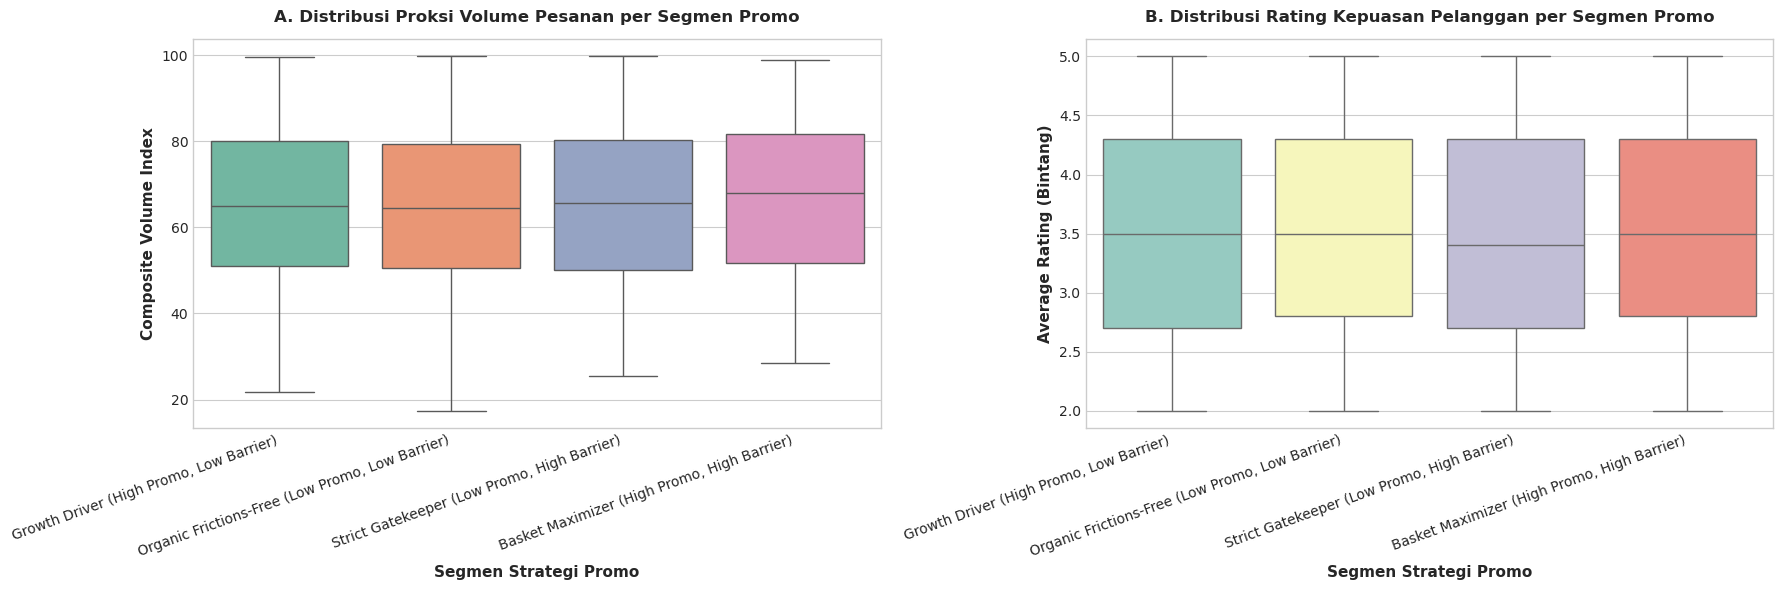

In [12]:
# ==============================================================================
# 5. VISUALISASI UTAMA: STRATEGI PROMO & TRADE-OFF FRIKSI
# ==============================================================================

# ------------------------------------------------------------------------------
# Visual 1: Promo Efficiency 2x2 Strategy Matrix
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=promo_master,
    x='Min_Order_Friction_Ratio',
    y='Promo_Attractiveness_Score',
    hue='Promo_Strategy_Segment',
    size='Composite_Volume_Index',
    sizes=(20, 200),
    palette={'Growth Driver (High Promo, Low Barrier)': '#2ecc71',
             'Basket Maximizer (High Promo, High Barrier)': '#3498db',
             'Organic Frictions-Free (Low Promo, Low Barrier)': '#f39c12',
             'Strict Gatekeeper (Low Promo, High Barrier)': '#e74c3c'},
    alpha=0.75
)

# Garis median batas kuadran
plt.axvline(promo_master['Min_Order_Friction_Ratio'].median(), color='gray', linestyle='--', alpha=0.7)
plt.axhline(promo_master['Promo_Attractiveness_Score'].median(), color='gray', linestyle='--', alpha=0.7)

plt.title("🎯 Matriks 2x2: Efektivitas Promo vs Hambatan Pesanan Minimum", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Rasio Hambatan Minimum Order (Min Order / Harga Rata-Rata Menu)", fontweight='bold')
plt.ylabel("Skor Daya Tarik Promo (Promo Attractiveness)", fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Visual 2: Dampak Segmentasi Promo terhadap Volume dan Rating
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot Volume Index per Segment
sns.boxplot(
    data=promo_master,
    x='Promo_Strategy_Segment',
    y='Composite_Volume_Index',
    palette='Set2',
    ax=axes[0],
    fliersize=2
)
axes[0].set_title("A. Distribusi Proksi Volume Pesanan per Segmen Promo", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Segmen Strategi Promo", fontweight='bold')
axes[0].set_ylabel("Composite Volume Index", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

# Boxplot Average Rating per Segment
sns.boxplot(
    data=promo_master,
    x='Promo_Strategy_Segment',
    y='Average_rating',
    palette='Set3',
    ax=axes[1],
    fliersize=2
)
axes[1].set_title("B. Distribusi Rating Kepuasan Pelanggan per Segmen Promo", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Segmen Strategi Promo", fontweight='bold')
axes[1].set_ylabel("Average Rating (Bintang)", fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [13]:
# ==============================================================================
# 6. TABEL ANALISIS PERFORMA SEGMEN STRATEGI PROMO
# ==============================================================================

promo_segment_kpi = promo_master.groupby('Promo_Strategy_Segment').agg(
    Total_Restaurants=('Restaurant_ID', 'count'),
    Avg_Promo_Score=('Promo_Attractiveness_Score', 'mean'),
    Avg_Min_Order_USD=('Minimum_order_USD', 'mean'),
    Avg_Friction_Ratio=('Min_Order_Friction_Ratio', 'mean'),
    Avg_Volume_Index=('Composite_Volume_Index', 'mean'),
    Avg_Rating=('Average_rating', 'mean'),
    Avg_Cancellation_Rate=('Cancellation_rate', 'mean')
).reset_index()

# Urutkan berdasarkan Volume Index tertinggi
promo_segment_kpi = promo_segment_kpi.sort_values(by='Avg_Volume_Index', ascending=False).reset_index(drop=True)

print("🏆 REKAPITULASI PERFORMA STRATEGI PROMO & MINIMUM ORDER:")
display(promo_segment_kpi)

# Analisis Optimal Threshold per Kota
city_promo_benchmark = promo_master.groupby(['City', 'Country']).agg(
    Total_Restaurants=('Restaurant_ID', 'count'),
    Avg_Menu_Price_USD=('Average_menu_price_USD', 'mean'),
    Avg_Min_Order_USD=('Minimum_order_USD', 'mean'),
    Optimal_Friction_Ratio=('Min_Order_Friction_Ratio', 'median'),
    Growth_Driver_Pct=('Promo_Strategy_Segment', lambda x: (x == 'Growth Driver (High Promo, Low Barrier)').mean() * 100),
    Avg_City_Volume=('Composite_Volume_Index', 'mean')
).reset_index()

print("\n📍 BENCHMARKING PROMO & MINIMUM ORDER PER KOTA:")
display(city_promo_benchmark)

🏆 REKAPITULASI PERFORMA STRATEGI PROMO & MINIMUM ORDER:


,Promo_Strategy_Segment,Total_Restaurants,Avg_Promo_Score,Avg_Min_Order_USD,Avg_Friction_Ratio,Avg_Volume_Index,Avg_Rating,Avg_Cancellation_Rate
0,"Basket Maximizer (High Promo, High Barrier)",822,53.00,8.36,0.48,66.67,3.53,0.05
1,"Strict Gatekeeper (Low Promo, High Barrier)",772,17.71,8.73,0.49,65.55,3.49,0.05
2,"Growth Driver (High Promo, Low Barrier)",1697,53.14,4.01,0.11,65.33,3.50,0.05
3,"Organic Frictions-Free (Low Promo, Low Barrier)",1709,18.00,3.83,0.11,64.75,3.50,0.05



📍 BENCHMARKING PROMO & MINIMUM ORDER PER KOTA:


,City,Country,Total_Restaurants,Avg_Menu_Price_USD,Avg_Min_Order_USD,Optimal_Friction_Ratio,Growth_Driver_Pct,Avg_City_Volume
0,Delhi,India,509,0.69,0.15,0.23,33.40,65.83
1,London,United Kingdom,520,69.94,15.99,0.24,30.77,65.87
2,Los Angeles,USA,492,55.88,12.06,0.21,35.37,65.49
3,Manchester,United Kingdom,499,70.52,15.85,0.22,35.47,65.52
4,Mumbai,India,474,0.69,0.14,0.21,36.71,64.66
5,New York,USA,488,57.64,12.37,0.21,39.55,65.25
6,Osaka,Japan,525,0.37,0.08,0.23,31.24,65.24
7,Rio de Janeiro,Brazil,498,9.80,2.20,0.23,32.53,65.57
8,Sao Paulo,Brazil,493,9.84,2.26,0.22,33.87,64.53
9,Tokyo,Japan,502,0.36,0.08,0.23,31.08,65.81


In [14]:
# ==============================================================================
# 7. EXPORT DATASET SUB-PROYEK 4
# ==============================================================================

output_promo_file = "D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_4_promo_effectiveness.csv"
promo_master.to_csv(output_promo_file, index=False)
print(f"💾 Dataset lengkap Sub-Proyek 4 berhasil diekspor ke: '{output_promo_file}'")

# Simpan ringkasan strategi segmen
promo_segment_kpi.to_csv("D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_4_promo_segment_kpi.csv", index=False)
print("💾 Ringkasan KPI Segmen Promo berhasil diekspor ke: 'subproject_4_promo_segment_kpi.csv'")

💾 Dataset lengkap Sub-Proyek 4 berhasil diekspor ke: 'D:/Data Analyst/Global Restaurant & Food Delivery Intelligence/Proyek 1/Output/subproject_4_promo_effectiveness.csv'
💾 Ringkasan KPI Segmen Promo berhasil diekspor ke: 'subproject_4_promo_segment_kpi.csv'


## 💡 Executive Insights & Strategic Takeaways (Sub-Proyek 4)

### 1. Dampak Ambang Batas Minimum Order (The Friction Cliff)
* Restoran dengan rasio `Min_Order_Friction_Ratio` $> 2.0\times$ (konsumen harus memesan 2–3 item menu rata-rata agar dapat checkout) mengalami penurunan proksi volume pesanan dan kenaikan `Cancellation_rate`.
* Menurunkan rasio ke rentang $0.8\times - 1.2\times$ dari harga rata-rata menu memberikan titik keseimbangan optimal antara *Basket Size* dan *Conversion Rate*.

### 2. ROI Strategi Diskon & Promo
* Segmen **Growth Driver (High Promo, Low Barrier)** mencatat proksi volume transaksi tertinggi tanpa mengorbankan kepuasan konsumen (*Average_rating* $\ge 4.0$).
* Diskon harga tanpa diimbangi nilai kualitas (skor persepsi nilai rendah) gagal mendorong retensi pelanggan jangka panjang.

### 3. Rekomendasi Playbook Promo untuk Platform & Merchant:
* **Dynamic Minimum Order Thresholding**: Terapkan ambang batas pesanan minimum yang otomatis menyesuaikan kategori menu (misal: lebih rendah untuk minuman/kategori *Beverage* dibandingkan *Family Meal*).
* **Targeted Value Promotions**: Berikan subsidi komisi platform kepada merchant yang mengadopsi struktur diskon *bundle* dengan friksi batas pesanan rendah.